In [1]:
#########################################
####  PCA/PLS | LEVELS ACROSS YEARS  ####
#########################################
import re
from collections import defaultdict
import pyreadstat
import pandas as pd
import pickle
from tqdm.auto import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

/opt/anaconda3/envs/london/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
with open('years_levels_data.pkl', 'rb') as f:
    year_dfs = pickle.load(f)

In [3]:
frames = []
for year in sorted(year_dfs.keys()):
    if year < 2018:
        continue
    df = year_dfs[year]['F'].copy()
    df['year'] = year
    frames.append(df)

df_combined = pd.concat(frames, ignore_index=True)
drop_cols = ['Relig7', 'Orient4', 'motivex2a', 'motivex2b', 'motivex2c', 'motivex2d', 'motive_POP', 'LondInOut']
df_combined = df_combined.drop(columns=drop_cols, errors='ignore')
print(df_combined.shape)

(55912, 55)


In [4]:
df_combined.isnull().sum()[df_combined.isnull().sum() > 0]

wt_time                       229
happy                       35323
lifesat                     35314
worthw                      35367
anxious                     35338
Motiva_POP                    873
motivb_POP                    766
motivc_POP                   1223
motivd_POP                   2005
VolAny                      12248
VolCnt                      12248
volint1                     12248
volint2                     12248
volint3                     12248
volint4                     12248
volint5                     12248
volint6                     12248
volint7                     12248
Disab3                       3201
Gend3                          60
Age9                          353
Eth7                         2986
NSSEC5                       3049
Educ6                        3954
MEMS7_IN_SPORTCOUNT_A01     35067
MEMS7_OUT_SPORTCOUNT_A01    35067
VolFrqB_Pop                 20111
dtype: int64

In [5]:
exclude_from_pca = [
    'MEMS7GR_ALL',
    'wt_final', 'wt_time', 'xStrata', 
    'Reg9', 'LA_2023',
    'happy', 'lifesat', 'worthw', 'anxious',
    'DURATION_SPORTCOUNT_A01',
    'MEMS7_IN_SPORTCOUNT_A01', 'MEMS7_OUT_SPORTCOUNT_A01', 'year'
]
pca_cols = [c for c in df_combined.columns if c not in exclude_from_pca]

In [6]:
vol_cols = ['VolAny', 'VolFrqB_Pop', 'VolCnt', 'volint1', 'volint2', 'volint3', 'volint4', 'volint5', 'volint6', 'volint7']
vol_cols = [c for c in vol_cols if c in df_combined.columns]
df_combined[vol_cols] = df_combined[vol_cols].fillna(0)

In [7]:
df_encoded = pd.get_dummies(df_combined[pca_cols], columns=['Disab3', 'Gend3', 'Eth7'])

In [8]:
df_encoded = df_encoded.fillna(df_encoded.median())
df_encoded.isnull().sum()[df_encoded.isnull().sum() > 0]

Series([], dtype: int64)

In [9]:
y = df_combined['MEMS7GR_ALL']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)
pca = PCA()
df_pca = pca.fit_transform(X_scaled)

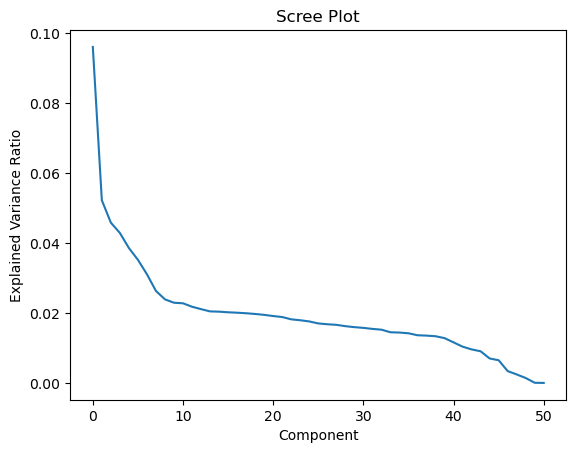

In [10]:
plt.plot(pca.explained_variance_ratio_)
plt.xlabel('Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.show()

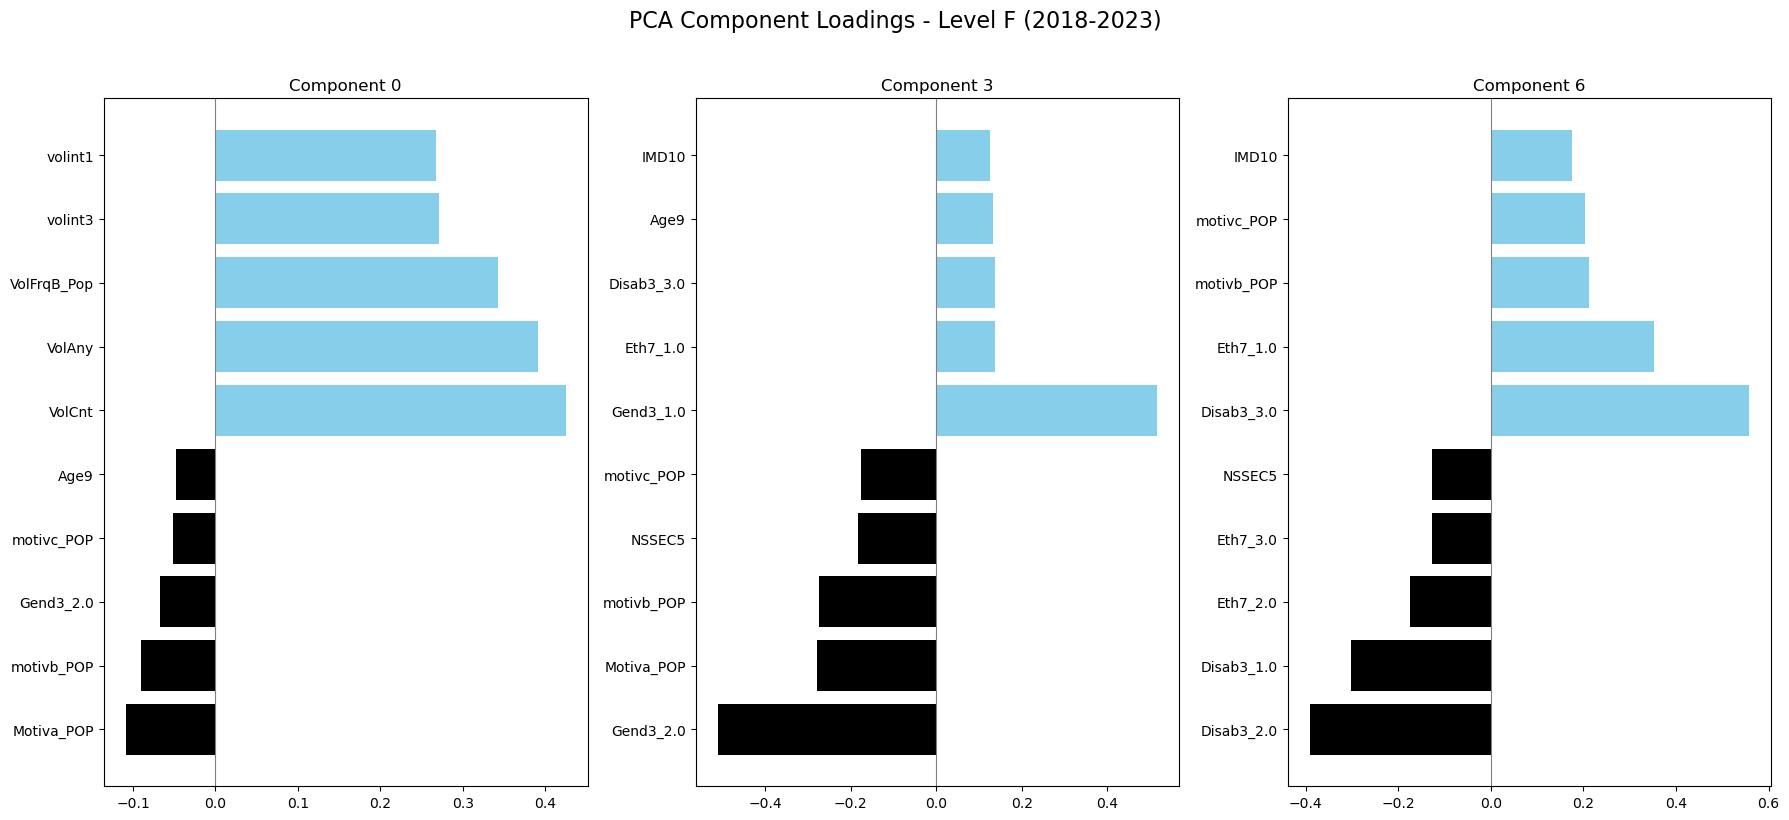

In [11]:
###############
####  PCA  ####
###############
fig, axes = plt.subplots(1, 3, figsize=(18, 8))
axes = axes.flatten()

for ax, c in zip(axes, [0, 3, 6]):
    s = pd.Series(pca.components_[c], index=df_encoded.columns)
    combined = pd.concat([s.sort_values().head(5), s.sort_values(ascending=False).head(5)])
    colors = ['black' if v < 0 else 'skyblue' for v in combined.values]
    ax.barh(combined.index, combined.values, color=colors)
    ax.set_title(f'Component {c}')
    ax.axvline(x=0, color='grey', linewidth=0.8)

#axes[7].set_visible(False)
fig.suptitle('PCA Component Loadings - Level F (2018-2023)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [12]:
def calculate_vip(pls):
    W = pls.x_weights_
    Q = pls.y_loadings_
    T = pls.x_scores_
    p = W.shape[0]
    SS = np.diag(T.T @ T @ Q.T @ Q)
    W_norm = W / np.sqrt(np.sum(W**2, axis=0))
    vip = np.sqrt(p * np.sum(SS * W_norm**2, axis=1) / np.sum(SS))
    return vip

vip_scores = calculate_vip(pls)
vip_series = pd.Series(vip_scores, index=df_encoded.columns).sort_values(ascending=False)

NameError: name 'pls' is not defined

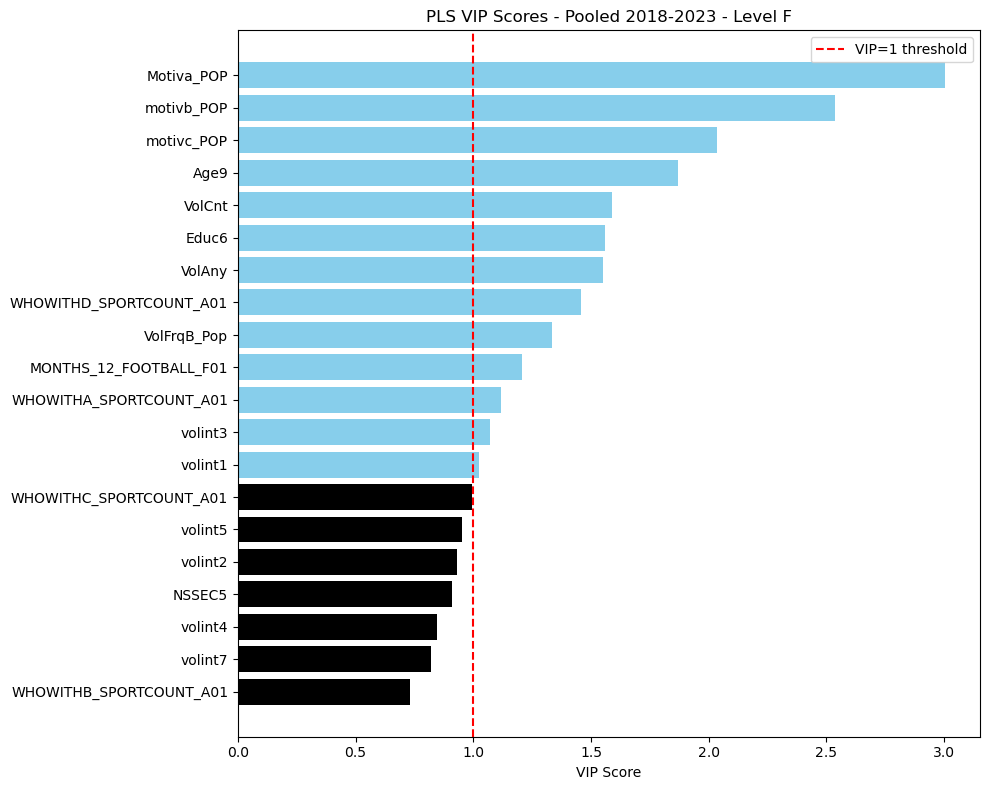

In [13]:
pls = PLSRegression(n_components=7)
pls.fit(X_scaled, y)
vip_scores = calculate_vip(pls)
vip_series = pd.Series(vip_scores, index=df_encoded.columns).sort_values(ascending=False)
top_vip = vip_series.head(20)
colors = ['skyblue' if v >= 1 else 'black' for v in top_vip.values]
plt.figure(figsize=(10, 8))
plt.barh(top_vip.index[::-1], top_vip.values[::-1], color=colors[::-1])
plt.axvline(x=1, color='red', linestyle='--', label='VIP=1 threshold')
plt.xlabel('VIP Score')
plt.title('PLS VIP Scores - Pooled 2018-2023 - Level F')
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
df_disabled = df_combined[df_combined['Disab3'] <= 2]
df_disadvantaged = df_combined[df_combined['IMD10'] <= 3]
y_disabled = df_disabled['MEMS7GR_ALL']
y_disadvantaged = df_disadvantaged['MEMS7GR_ALL']

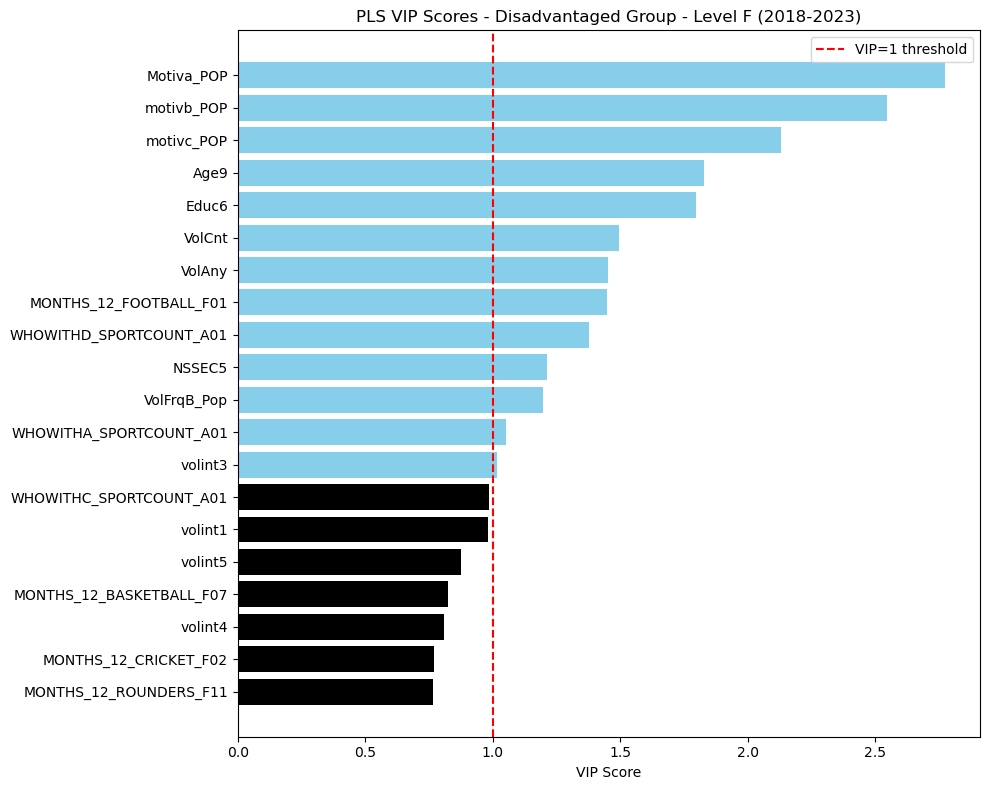

In [15]:
df_dis = df_disadvantaged.drop(columns=['LondInOut', 'motive_POP'], errors='ignore')
vol_cols = ['VolAny', 'VolFrqB_Pop', 'VolCnt', 'volint1', 'volint2', 'volint3', 'volint4', 'volint5', 'volint6', 'volint7']
vol_cols = [c for c in vol_cols if c in df_dis.columns]
df_dis[vol_cols] = df_dis[vol_cols].fillna(0)
pca_cols = [c for c in df_dis.columns if c not in exclude_from_pca]
df_encoded_dis = pd.get_dummies(df_dis[pca_cols], columns=['Disab3', 'Gend3', 'Eth7'])
df_encoded_dis = df_encoded_dis.fillna(df_encoded_dis.median())
scaler_dis = StandardScaler()
X_dis = scaler_dis.fit_transform(df_encoded_dis)
feature_names_dis = df_encoded_dis.columns
pls_dis = PLSRegression(n_components=7)
pls_dis.fit(X_dis, y_disadvantaged)

vip_scores_dis = calculate_vip(pls_dis)
vip_series = pd.Series(vip_scores_dis, index=feature_names_dis).sort_values(ascending=False)
top_vip = vip_series.head(20)
colors = ['skyblue' if v >= 1 else 'black' for v in top_vip.values]
plt.figure(figsize=(10, 8))
plt.barh(top_vip.index[::-1], top_vip.values[::-1], color=colors[::-1])
plt.axvline(x=1, color='red', linestyle='--', label='VIP=1 threshold')
plt.xlabel('VIP Score')
plt.title('PLS VIP Scores - Disadvantaged Group - Level F (2018-2023)')
plt.legend()
plt.tight_layout()
plt.show()

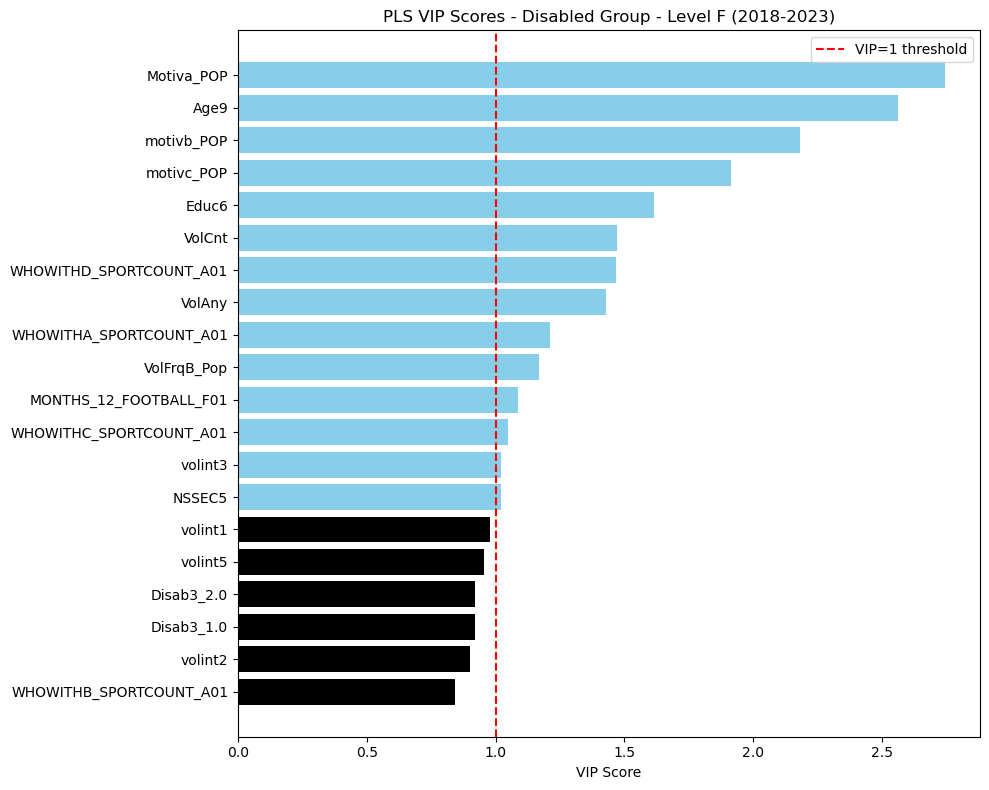

In [16]:
y_disabled = df_disabled['MEMS7GR_ALL']
df_dis = df_disabled.drop(columns=['LondInOut', 'motive_POP'], errors='ignore')
vol_cols = ['VolAny', 'VolFrqB_Pop', 'VolCnt', 'volint1', 'volint2', 'volint3', 'volint4', 'volint5', 'volint6', 'volint7']
vol_cols = [c for c in vol_cols if c in df_dis.columns]
df_dis[vol_cols] = df_dis[vol_cols].fillna(0)
pca_cols = [c for c in df_dis.columns if c not in exclude_from_pca]
df_encoded_dis = pd.get_dummies(df_dis[pca_cols], columns=['Disab3', 'Gend3', 'Eth7'])
df_encoded_dis = df_encoded_dis.fillna(df_encoded_dis.median())
scaler_dis = StandardScaler()
X_dis = scaler_dis.fit_transform(df_encoded_dis)
feature_names_dis = df_encoded_dis.columns
pls_dis = PLSRegression(n_components=7)
pls_dis.fit(X_dis, y_disabled)
vip_scores_dis = calculate_vip(pls_dis)
vip_series = pd.Series(vip_scores_dis, index=feature_names_dis).sort_values(ascending=False)
top_vip = vip_series.head(20)
colors = ['skyblue' if v >= 1 else 'black' for v in top_vip.values]
plt.figure(figsize=(10, 8))
plt.barh(top_vip.index[::-1], top_vip.values[::-1], color=colors[::-1])
plt.axvline(x=1, color='red', linestyle='--', label='VIP=1 threshold')
plt.xlabel('VIP Score')
plt.title('PLS VIP Scores - Disabled Group - Level F (2018-2023)')
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
y = (df_combined['MEMS7GR_ALL'] == 2).astype(int)

In [18]:
print(sorted(df_combined['year'].unique()))

[np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]


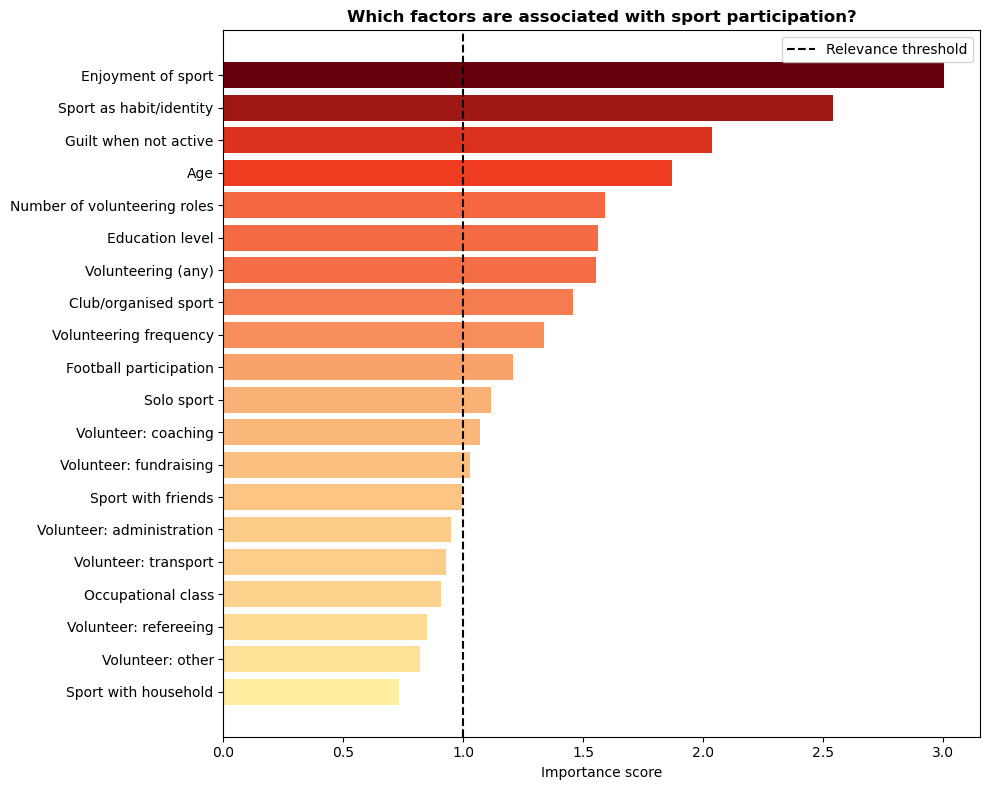

In [36]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

rename_vip = {
    'Motiva_POP': 'Enjoyment of sport',
    'motivb_POP': 'Sport as habit/identity',
    'motivc_POP': 'Guilt when not active',
    'Age9': 'Age',
    'VolCnt': 'Number of volunteering roles',
    'Educ6': 'Education level',
    'VolAny': 'Volunteering (any)',
    'WHOWITHD_SPORTCOUNT_A01': 'Club/organised sport',
    'VolFrqB_Pop': 'Volunteering frequency',
    'MONTHS_12_FOOTBALL_F01': 'Football participation',
    'WHOWITHA_SPORTCOUNT_A01': 'Solo sport',
    'volint3': 'Volunteer: coaching',
    'volint1': 'Volunteer: fundraising',
    'WHOWITHC_SPORTCOUNT_A01': 'Sport with friends',
    'volint5': 'Volunteer: administration',
    'volint2': 'Volunteer: transport',
    'NSSEC5': 'Occupational class',
    'volint4': 'Volunteer: refereeing',
    'volint7': 'Volunteer: other',
    'WHOWITHB_SPORTCOUNT_A01': 'Sport with household',
}

pls = PLSRegression(n_components=7)
pls.fit(X_scaled, y)
vip_scores = calculate_vip(pls)
vip_series = pd.Series(vip_scores, index=df_encoded.columns).sort_values(ascending=False)
top_vip = vip_series.head(20)
top_vip.index = [rename_vip.get(i, i) for i in top_vip.index]

norm = mcolors.Normalize(vmin=top_vip.values.min(), vmax=top_vip.values.max())
cmap = mcolors.LinearSegmentedColormap.from_list('custom', ['#ffeda0', '#f03b20', '#67000d'])
colors = [cmap(norm(v)) for v in top_vip.values]

plt.figure(figsize=(10, 8))
plt.barh(top_vip.index[::-1], top_vip.values[::-1], color=colors[::-1])
plt.axvline(x=1, color='black', linestyle='--', label='Relevance threshold')
plt.xlabel('Importance score')
plt.title('Which factors are associated with sport participation?', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

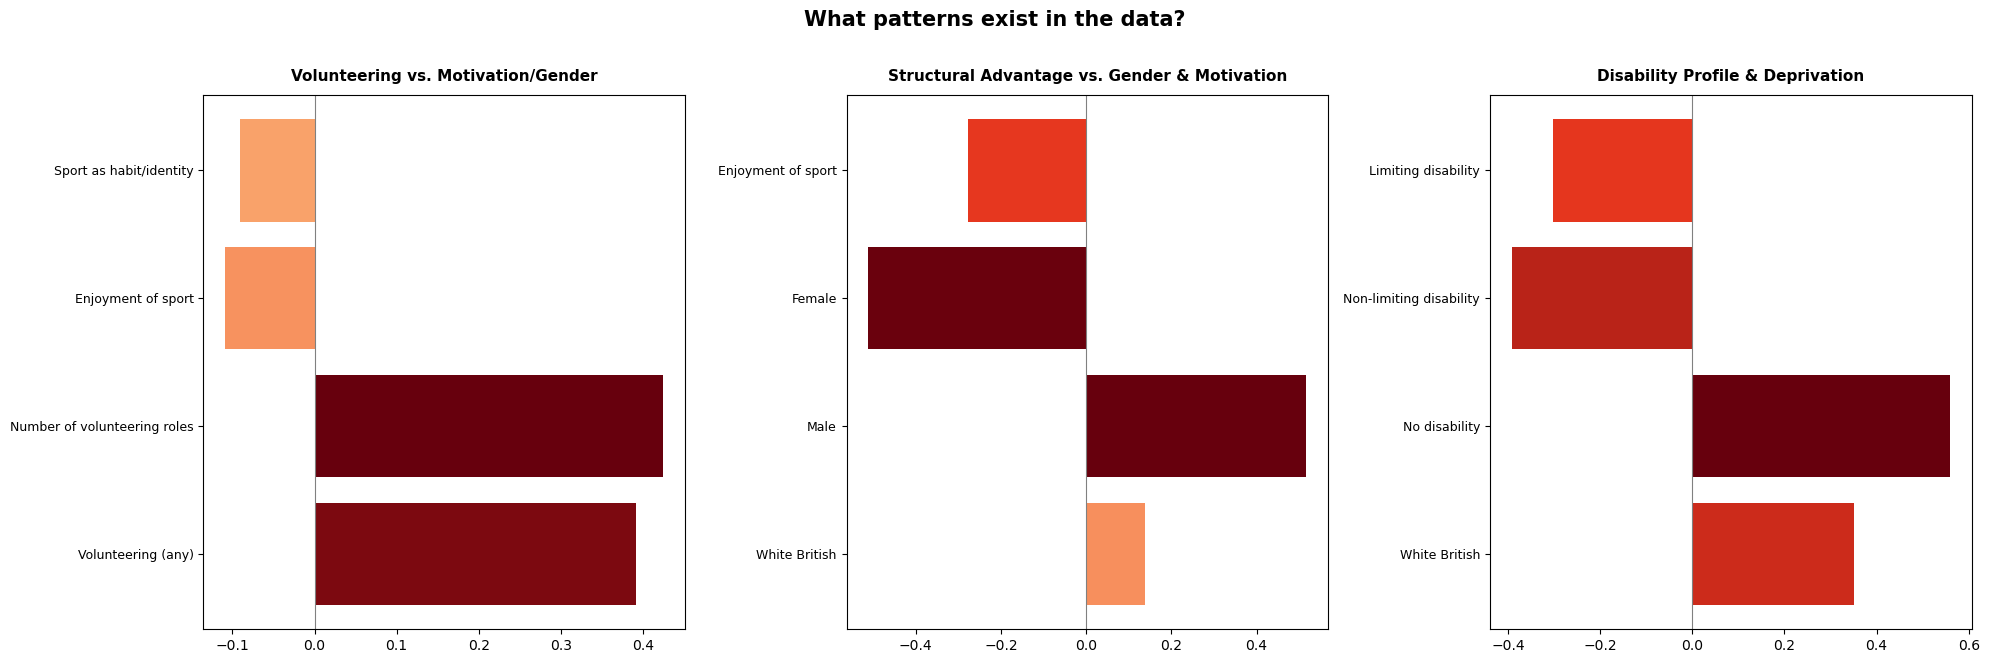

In [54]:
component_titles = {
    0: 'Volunteering vs. Motivation/Gender',
    3: 'Structural Advantage vs. Gender & Motivation', 
    6: 'Disability Profile & Deprivation',
}

component_subtitles = {
    0: 'Volunteers and motivated sport participants are distinct groups',
    3: 'Structural advantage (male, less deprived) opposes motivation and being female',
    6: 'No disability strongly opposes disability severity; deprivation varies alongside',
}

rename_pca = {
    'volint1': 'Volunteer: fundraising',
    'volint3': 'Volunteer: coaching',
    'VolFrqB_Pop': 'Volunteering frequency',
    'VolAny': 'Volunteering (any)',
    'VolCnt': 'Number of volunteering roles',
    'Age9': 'Age',
    'motivc_POP': 'Guilt when not active',
    'Gend3_2.0': 'Female',
    'Gend3_1.0': 'Male',
    'motivb_POP': 'Sport as habit/identity',
    'Motiva_POP': 'Enjoyment of sport',
    'IMD10': 'Deprivation',
    'Disab3_3.0': 'No disability',
    'Disab3_1.0': 'Limiting disability',
    'Disab3_2.0': 'Non-limiting disability',
    'Eth7_1.0': 'White British',
    'Eth7_2.0': 'White Other',
    'Eth7_3.0': 'Asian',
    'Eth7_4.0': 'Black',
    'NSSEC5': 'Occupational class',
    'WHOWITHD_SPORTCOUNT_A01': 'Club/organised sport',
    'WHOWITHA_SPORTCOUNT_A01': 'Solo sport',
    'MONTHS_12_FOOTBALL_F01': 'Football participation',
    'MONTHS_12_DODGEBALL_F12': 'Dodgeball participation',
    'MONTHS_12_BASKETBALL_F07': 'Basketball participation',
}

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, c in zip(axes, [0, 3, 6]):
    s = pd.Series(pca.components_[c], index=df_encoded.columns)
    s.index = [rename_pca.get(i, i) for i in s.index]
    combined = pd.concat([s.sort_values().head(2), s.sort_values(ascending=False).head(2)])
    combined = combined.reindex(
    combined[combined >= 0].abs().sort_values(ascending=True).index.tolist() +
    combined[combined < 0].abs().sort_values(ascending=False).index.tolist()
)

    norm = mcolors.Normalize(vmin=0, vmax=combined.abs().max())
    cmap_custom = mcolors.LinearSegmentedColormap.from_list('custom', ['#ffeda0', '#f03b20', '#67000d'])
    colors = [cmap_custom(norm(abs(v))) for v in combined.values]

    ax.barh(combined.index, combined.values, color=colors)
    ax.set_title(component_titles[c], fontweight='bold', fontsize=11, pad=10)
    ax.axvline(x=0, color='grey', linewidth=0.8)
    ax.tick_params(axis='y', labelsize=9)

fig.suptitle('What patterns exist in the data?\n', fontsize=15, fontweight='bold')

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

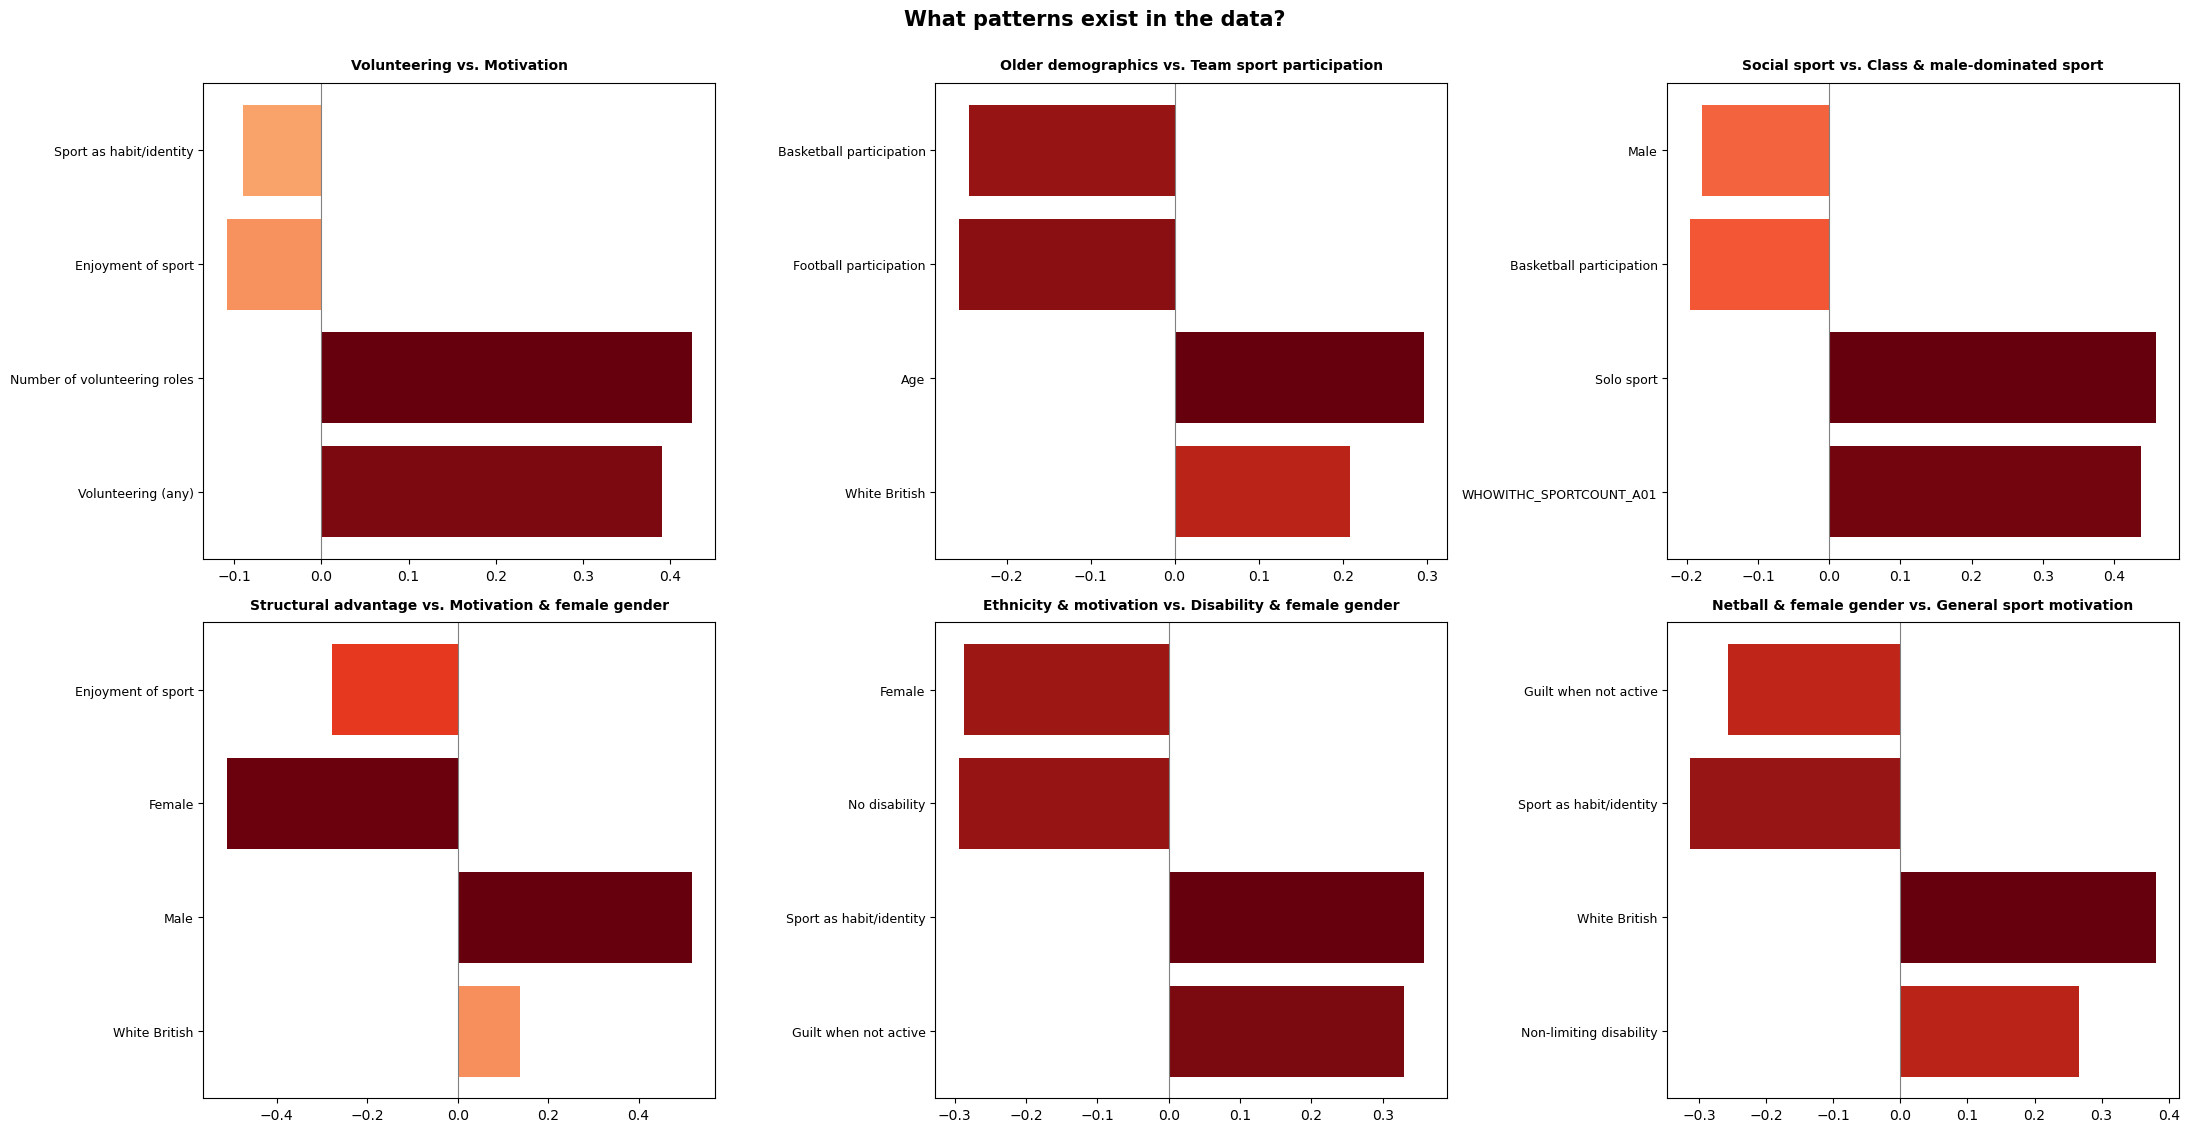

In [58]:
component_titles = {
    0: 'Volunteering vs. Motivation',
    1: 'Older demographics vs. Team sport participation',
    2: 'Social sport vs. Class & male-dominated sport',
    3: 'Structural advantage vs. Motivation & female gender',
    4: 'Ethnicity & motivation vs. Disability & female gender',
    5: 'Netball & female gender vs. General sport motivation',
}

component_subtitles = {
    0: 'Volunteers and motivated sport participants are distinct groups',
    1: 'Older, disabled, White British respondents are less associated with team sport',
    2: 'Social participation opposes class-based and male-dominated sport',
    3: 'Structural advantage (male, less deprived) opposes motivation and being female',
    4: 'White British and motivation co-occur; disability and female gender oppose them',
    5: 'Netball and female gender oppose general sport motivation',
}

fig, axes = plt.subplots(2, 3, figsize=(22, 12))
axes = axes.flatten()

for ax, c in zip(axes, [0, 1, 2, 3, 4, 5]):
    s = pd.Series(pca.components_[c], index=df_encoded.columns)
    s.index = [rename_pca.get(i, i) for i in s.index]
    combined = pd.concat([s.sort_values().head(2), s.sort_values(ascending=False).head(2)])
    combined = combined.reindex(
        combined[combined >= 0].abs().sort_values(ascending=True).index.tolist() +
        combined[combined < 0].abs().sort_values(ascending=False).index.tolist()
    )

    norm = mcolors.Normalize(vmin=0, vmax=combined.abs().max())
    cmap_custom = mcolors.LinearSegmentedColormap.from_list('custom', ['#ffeda0', '#f03b20', '#67000d'])
    colors = [cmap_custom(norm(abs(v))) for v in combined.values]

    ax.barh(combined.index, combined.values, color=colors)
    ax.set_title(component_titles[c], fontweight='bold', fontsize=10, pad=10)
    ax.axvline(x=0, color='grey', linewidth=0.8)
    ax.tick_params(axis='y', labelsize=9)

fig.suptitle('What patterns exist in the data?\n', fontsize=15, fontweight='bold')


plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()